## ヒストグラム可視化

In [1]:
import polars as pl
data_pl = pl.read_csv(r"../data/train.csv",encoding="shift_jis")

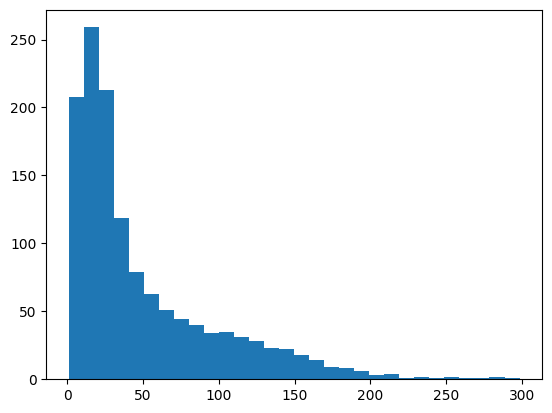

In [2]:
import matplotlib.pyplot as plt

data_pl["含水率"].to_numpy()

plt.hist(data_pl["含水率"].to_numpy(), bins=30)
plt.show()

In [4]:
species_list = data_pl["樹種"].unique().to_list()

----- スプルース
樹種 スプルース


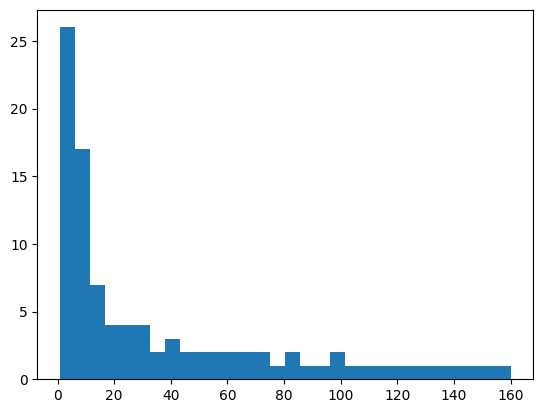

----- 米ヒバ
樹種 米ヒバ


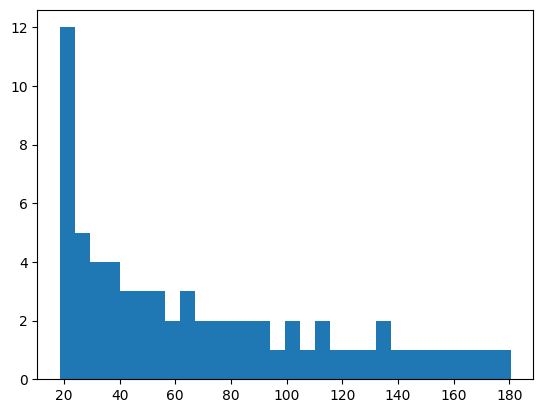

----- ベイスギ
樹種 ベイスギ


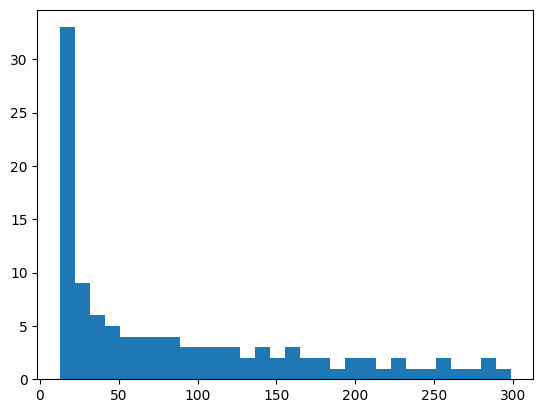

----- ウエンジ
樹種 ウエンジ


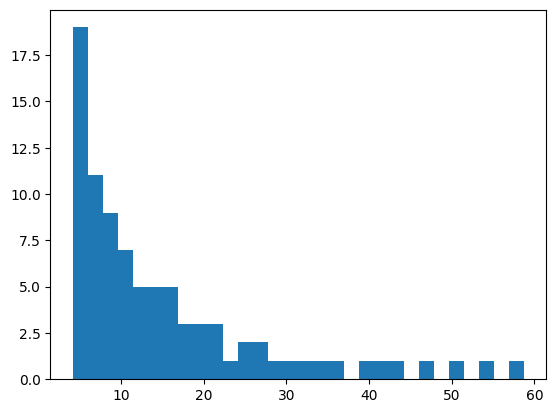

----- ウォールナット
樹種 ウォールナット


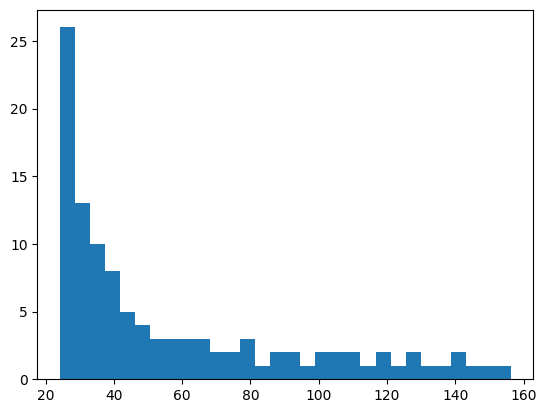

----- ヒノキ
樹種 ヒノキ


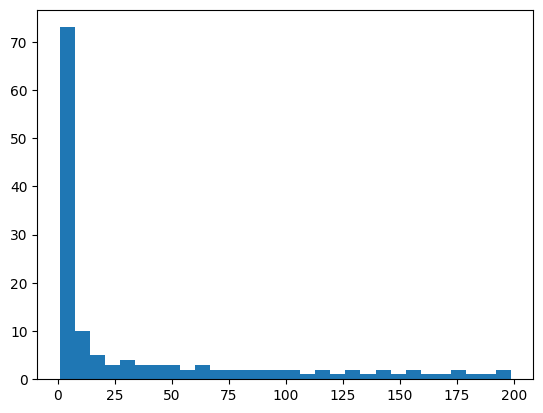

----- ホワイトオーク
樹種 ホワイトオーク


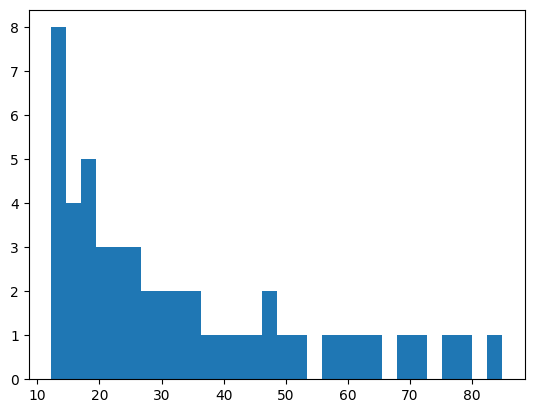

----- チェリー
樹種 チェリー


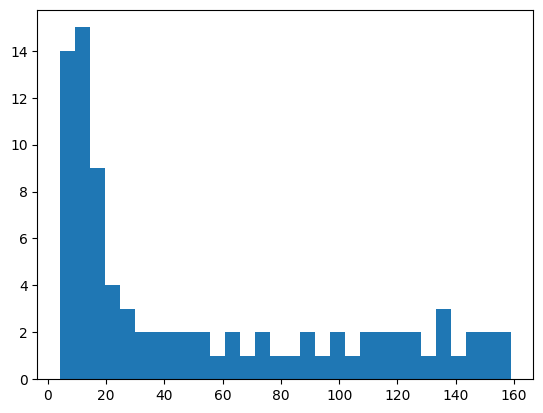

----- トチ
樹種 トチ


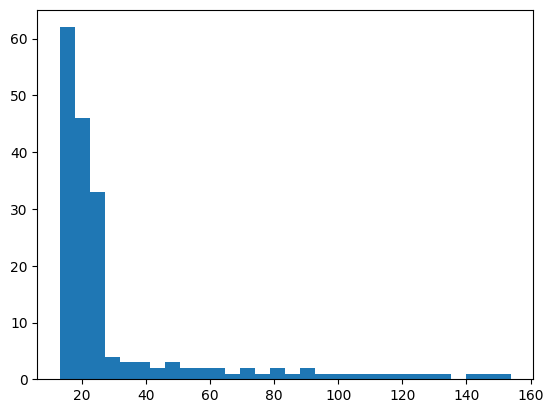

----- ベイマツ
樹種 ベイマツ


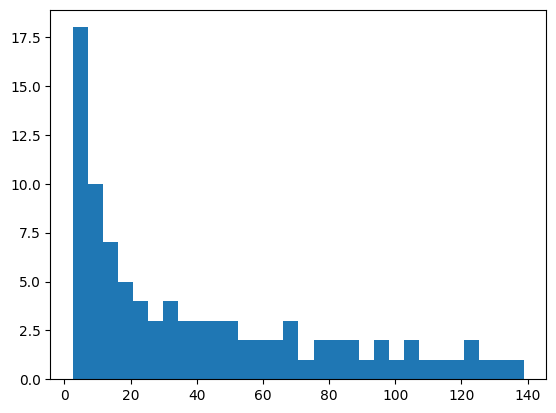

----- ナラ
樹種 ナラ


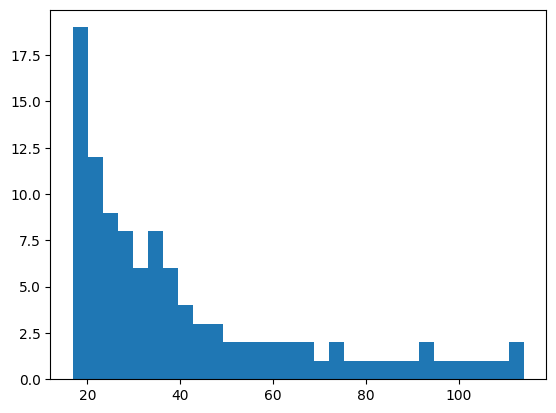

----- イチョウ
樹種 イチョウ


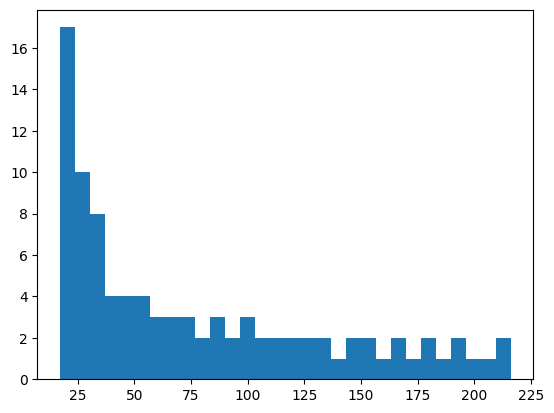

----- クリ
樹種 クリ


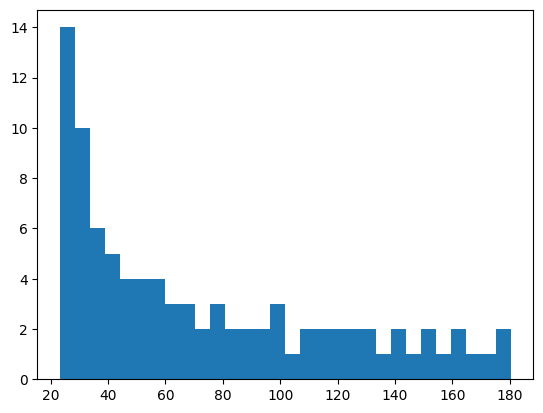

In [10]:
species_list = data_pl["樹種"].unique().to_list()

for sp in species_list:
    print("-----")
    print("樹種",sp)
    values = data_pl.filter(pl.col("樹種") == sp)\
               .select(pl.col("含水率").drop_nulls())\
               .to_series()\
               .to_numpy()

    plt.hist(values, bins=30)
    plt.show()

In [6]:
data_new = data_pl.with_columns(
    pl.col("含水率").log().alias("含水率_log")
)

-----
樹種 スプルース


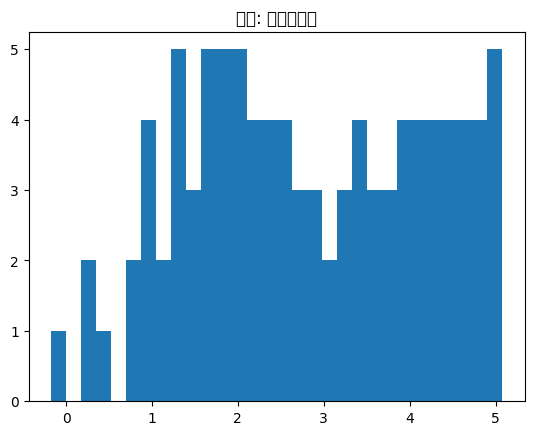

-----
樹種 米ヒバ


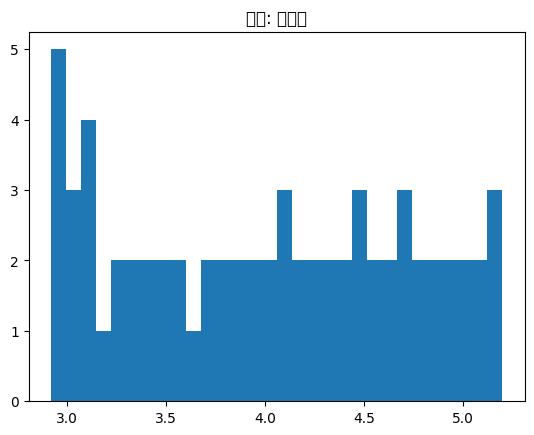

-----
樹種 ベイスギ


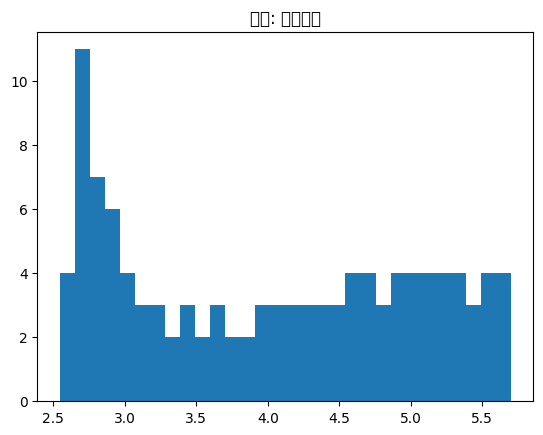

-----
樹種 ウエンジ


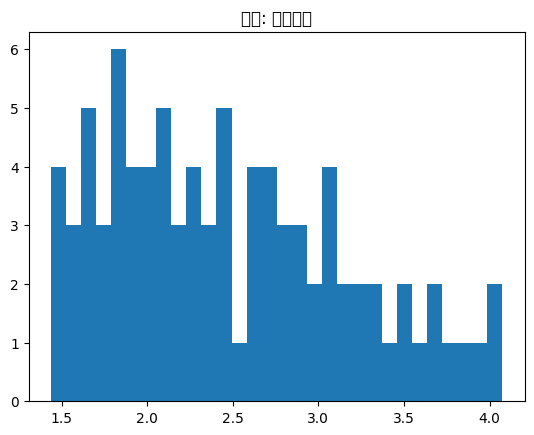

-----
樹種 ウォールナット


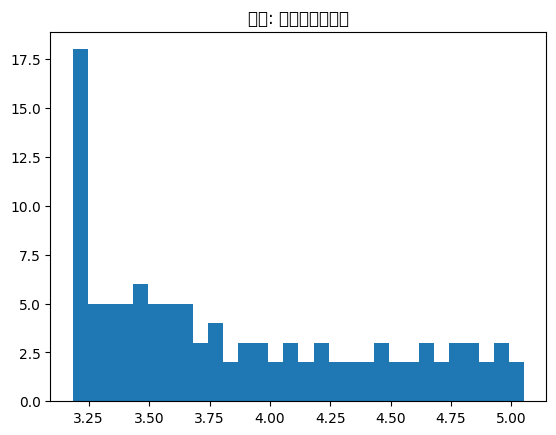

-----
樹種 ヒノキ


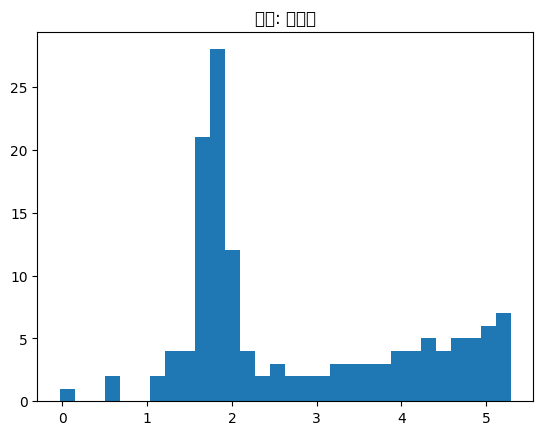

-----
樹種 ホワイトオーク


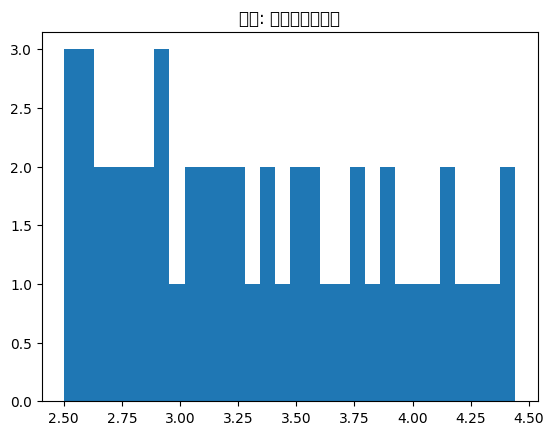

-----
樹種 チェリー


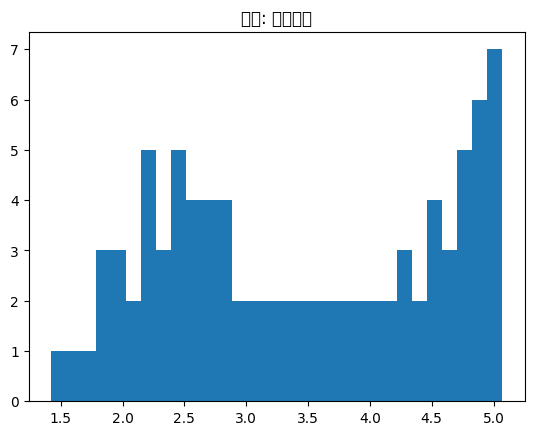

-----
樹種 トチ


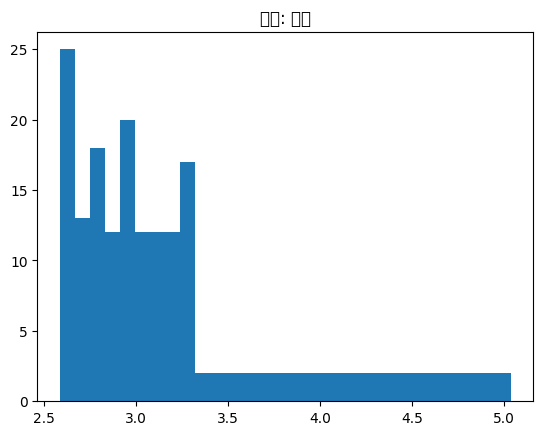

-----
樹種 ベイマツ


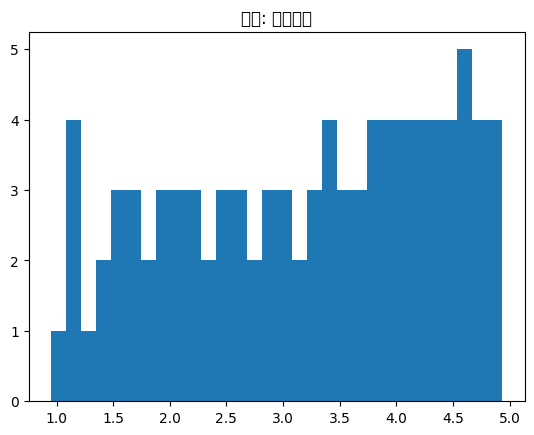

-----
樹種 ナラ


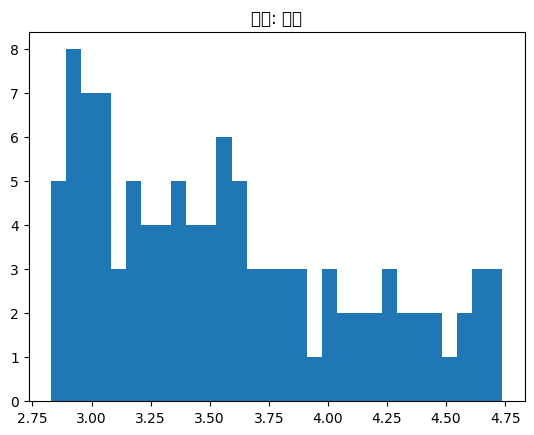

-----
樹種 イチョウ


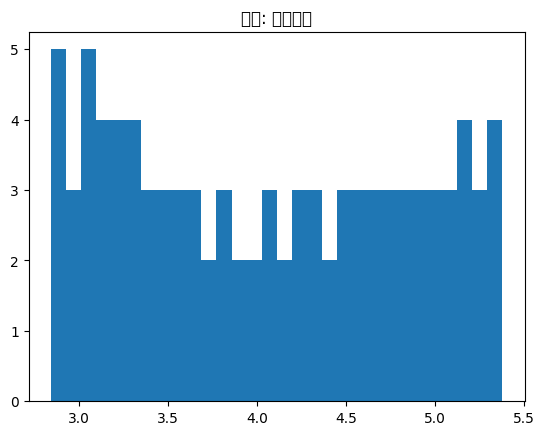

-----
樹種 クリ


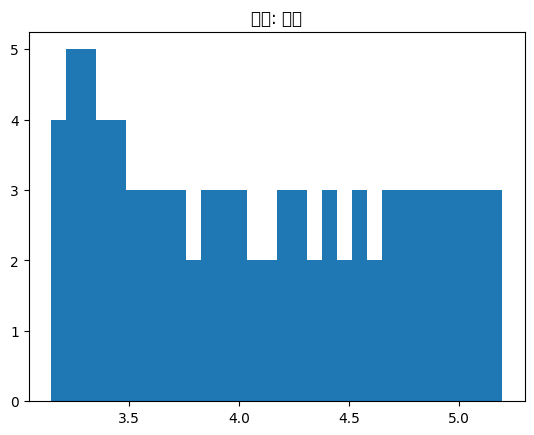

In [11]:
for sp in species_list:
    print("-----")
    print("樹種",sp)
    values = data_new.filter(pl.col("樹種") == sp)\
               .select(pl.col("含水率_log").drop_nulls())\
               .to_series()\
               .to_numpy()

    plt.hist(values, bins=30)
    plt.title(f"樹種: {sp}")
    plt.show()